# 04 — Draft Pedigree, Aging Curves, and Hidden Gems

This notebook looks at player *development* over time rather than a single-season snapshot: does draft
capital (round/pick) predict a player's Madden rating and real production; does college pedigree add
anything beyond draft round; when do players of different positions peak and decline (Madden rating and
real performance both); and which players most outperform the "priors" (draft slot, Madden rating) that
would normally predict their production — the hidden gems.

Data: `data/processed/players_merged.csv`, which already carries each matched player's real draft year/
round/pick and years of experience from the nflverse bio table (`build_dataset.py`), so no additional data
pull is needed for the draft-capital analysis. `college` (already present) is used as a pedigree proxy via
the "blue-blood" grouping established in notebook 01.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

df = pd.read_csv("../data/processed/players_merged.csv")
df_real = df[df["real_match_score"] >= 90].copy()
print(f"Full Madden roster: {len(df)}, confidently matched to real data: {len(df_real)}")
print(f"Players with a known draft round: {df_real['real_draft_round'].notna().sum()} "
      f"({100 * df_real['real_draft_round'].notna().mean():.1f}%)")
print(f"Undrafted (draft round NaN but bio matched): "
      f"{(df_real['real_draft_round'].isna() & df_real['real_draft_year'].notna()).sum()}")

Full Madden roster: 2015, confidently matched to real data: 1638
Players with a known draft round: 1227 (74.9%)
Undrafted (draft round NaN but bio matched): 0


## 1. Draft capital -> Madden rating

We bucket players into draft round (1-7) or undrafted (UDFA), and compare Madden's overall `rating`
across buckets. Because rating is also a function of games played/track record (a 10-year veteran 7th
rounder who stuck around is a survivor, not a typical 7th-round outcome), we show both the full sample and
a "young players only" cut (`years_pro <= 3`) which is closer to a clean draft-slot signal before survivor
bias sets in.

Players with known draft outcome (drafted or confirmed UDFA): 1227


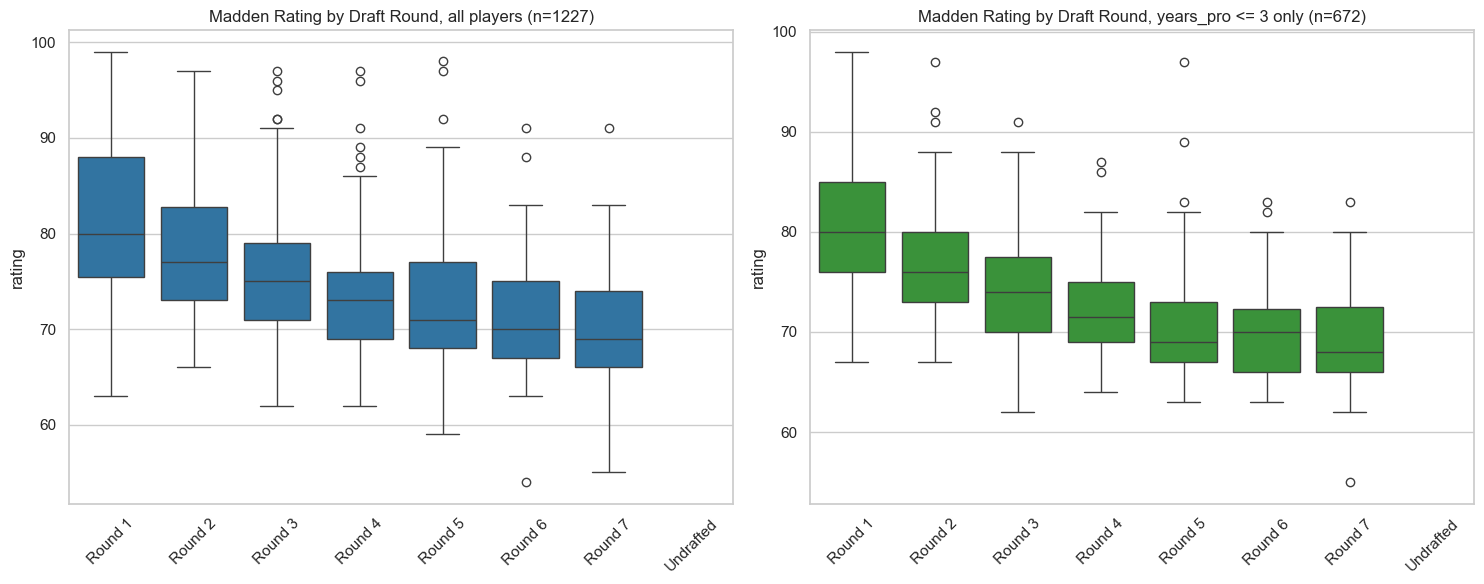

draft_bucket
Round 1      80.0
Round 2      77.0
Round 3      75.0
Round 4      73.0
Round 5      71.0
Round 6      70.0
Round 7      69.0
Undrafted     NaN
Name: rating, dtype: float64


In [2]:
df_real["draft_bucket"] = df_real["real_draft_round"].apply(
    lambda r: f"Round {int(r)}" if pd.notna(r) else "Undrafted"
)
bucket_order = [f"Round {i}" for i in range(1, 8)] + ["Undrafted"]

has_draft_info = df_real[df_real["real_draft_year"].notna()].copy()
print(f"Players with known draft outcome (drafted or confirmed UDFA): {len(has_draft_info)}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=has_draft_info, x="draft_bucket", y="rating", order=bucket_order, ax=axes[0], color="#1f77b4")
axes[0].set_title(f"Madden Rating by Draft Round, all players (n={len(has_draft_info)})")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

young = has_draft_info[has_draft_info["years_pro"] <= 3]
sns.boxplot(data=young, x="draft_bucket", y="rating", order=bucket_order, ax=axes[1], color="#2ca02c")
axes[1].set_title(f"Madden Rating by Draft Round, years_pro <= 3 only (n={len(young)})")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(has_draft_info.groupby("draft_bucket")["rating"].median().reindex(bucket_order))

In [3]:
r_pick, p_pick = stats.pearsonr(
    has_draft_info.dropna(subset=["real_draft_pick"])["real_draft_pick"],
    has_draft_info.dropna(subset=["real_draft_pick"])["rating"],
)
print(f"Overall draft pick number vs Madden rating: Pearson r = {r_pick:.3f} (p = {p_pick:.2e}, n={has_draft_info['real_draft_pick'].notna().sum()})")
print("(negative r expected: lower pick number = drafted earlier = higher rating)")

Overall draft pick number vs Madden rating: Pearson r = -0.472 (p = 3.70e-69, n=1227)
(negative r expected: lower pick number = drafted earlier = higher rating)


**Takeaway:** Madden rating declines steadily from round 1 through round 7 and is lowest for undrafted
players, both in the full sample and the young-players-only cut, and draft pick number correlates
negatively with rating as expected. This makes sense mechanically as much as talent-wise: rating partly
reflects role/reps, and earlier picks get first crack at starting jobs, but the young-only cut (which
controls for the "aged into a job" survivor effect) shows the relationship isn't purely about tenure —
draft slot itself carries real signal about Madden's assessment of ability, mirroring how NFL front offices
themselves treat draft capital as a strong prior.

## 2. Draft capital -> real 2025 performance (QB and WR)

Sample sizes get small once we require both a draft round and a meaningful 2025 workload, so we restrict
this cut to QB and WR — the two positions with individually-attributable efficiency stats and (from
notebook 02/03) the clearest rating-to-performance link.

Qualifying QBs with known draft outcome: 42 / 43
Qualifying WRs with known draft outcome: 99 / 111


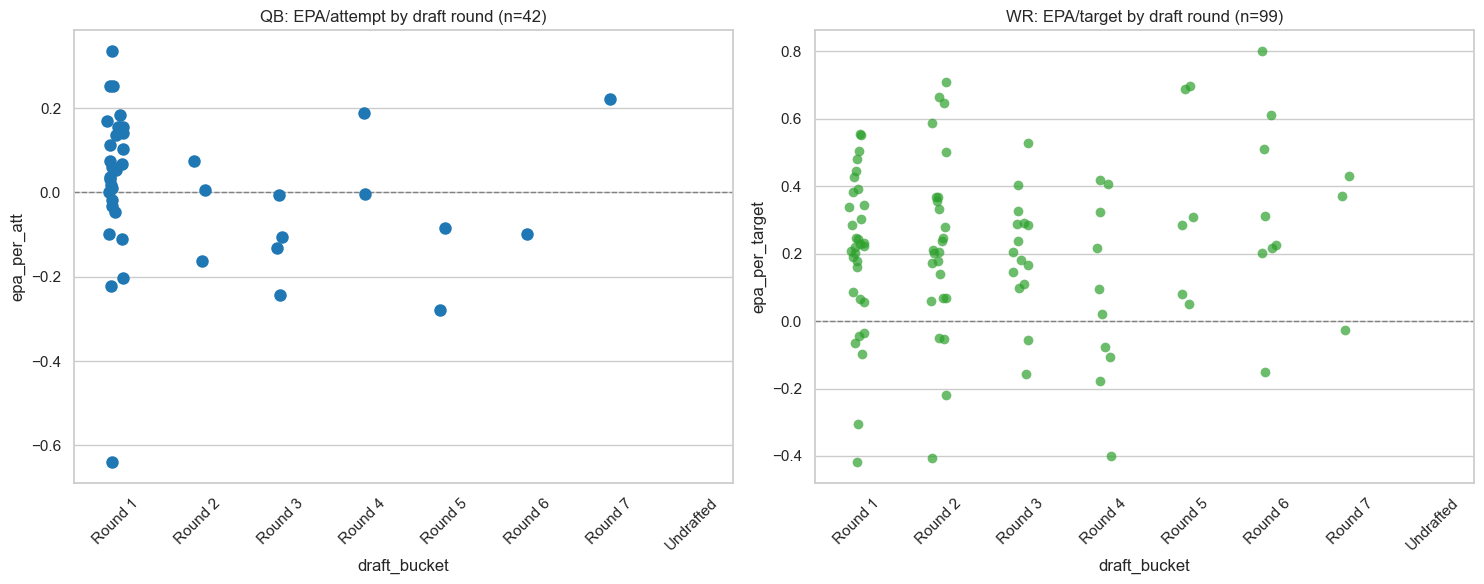

In [4]:
qb = df_real[(df_real["position_group"] == "QB") & (df_real["real_games"] >= 6) & (df_real["real_attempts"] > 0)].copy()
qb["epa_per_att"] = qb["real_passing_epa"] / qb["real_attempts"]
qb["draft_bucket"] = qb["real_draft_round"].apply(lambda r: f"Round {int(r)}" if pd.notna(r) else "Undrafted")

wr = df_real[(df_real["position_group"] == "WR") & (df_real["real_targets"] >= 30)].copy()
wr["epa_per_target"] = wr["real_receiving_epa"] / wr["real_targets"]
wr["draft_bucket"] = wr["real_draft_round"].apply(lambda r: f"Round {int(r)}" if pd.notna(r) else "Undrafted")

print(f"Qualifying QBs with known draft outcome: {qb['real_draft_year'].notna().sum()} / {len(qb)}")
print(f"Qualifying WRs with known draft outcome: {wr['real_draft_year'].notna().sum()} / {len(wr)}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.stripplot(data=qb.dropna(subset=["real_draft_year"]), x="draft_bucket", y="epa_per_att",
              order=[b for b in bucket_order if b in qb["draft_bucket"].values], ax=axes[0], size=9, color="#1f77b4")
axes[0].axhline(0, color="grey", ls="--", lw=1)
axes[0].set_title(f"QB: EPA/attempt by draft round (n={qb['real_draft_year'].notna().sum()})")
axes[0].tick_params(axis="x", rotation=45)

sns.stripplot(data=wr.dropna(subset=["real_draft_year"]), x="draft_bucket", y="epa_per_target",
              order=[b for b in bucket_order if b in wr["draft_bucket"].values], ax=axes[1], size=7, color="#2ca02c", alpha=0.7)
axes[1].axhline(0, color="grey", ls="--", lw=1)
axes[1].set_title(f"WR: EPA/target by draft round (n={wr['real_draft_year'].notna().sum()})")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Takeaway:** at both positions there's a visible tendency for early-round picks to cluster toward the top
of the real efficiency distribution, but the relationship is far looser than for Madden rating itself —
several day-2/day-3 picks and undrafted players post 2025 efficiency numbers competitive with (or better
than) first-round picks, especially at WR where day-3 hit rates are famously higher than at QB. With only
~15-40 qualifying players per position this is descriptive, not a rigorously powered test, but it's
consistent with the well-known finding in football analytics that draft slot is a much noisier predictor of
*realized* performance than of *opportunity* (which is closer to what Madden rating reflects).

## 3. College pedigree, controlling for draft round

Using the "blue-blood" top-20 programs identified by roster share in notebook 01, we check whether college
pedigree predicts Madden rating *beyond* what draft round already captures — i.e., do blue-blood players
outperform non-blue-blood players drafted in the same round (development/coaching pipeline effect), or does
draft capital fully explain the blue-blood rating edge (selection effect only)?

In [5]:
blue_bloods = set(df_real["college"].value_counts().head(20).index)
has_draft_info["is_blue_blood"] = has_draft_info["college"].isin(blue_bloods)

print(f"Blue-blood programs (top 20 by Madden roster share): {sorted(blue_bloods)}")
print()
overall_diff = has_draft_info.groupby("is_blue_blood")["rating"].mean()
print("Overall mean rating, blue-blood vs not:")
print(overall_diff)
print()

by_round = has_draft_info.dropna(subset=["real_draft_round"]).groupby(
    ["draft_bucket", "is_blue_blood"]
)["rating"].agg(["mean", "count"]).reset_index()
by_round_pivot = by_round.pivot(index="draft_bucket", columns="is_blue_blood", values="mean").reindex(
    [b for b in bucket_order if b != "Undrafted"]
)
by_round_pivot.columns = ["Not blue-blood", "Blue-blood"]
by_round_pivot["gap"] = by_round_pivot["Blue-blood"] - by_round_pivot["Not blue-blood"]
by_round_pivot

Blue-blood programs (top 20 by Madden roster share): ['Alabama', 'Clemson', 'Florida', 'Georgia', 'Iowa', 'LSU', 'Michigan', 'Notre Dame', 'Ohio State', 'Oklahoma', 'Oregon', 'Penn State', 'Stanford', 'Tennessee', 'Texas', 'Texas AM', 'UCLA', 'USC', 'Washington', 'Wisconsin']

Overall mean rating, blue-blood vs not:
is_blue_blood
False    74.826215
True     76.996350
Name: rating, dtype: float64



,Not blue-blood,Blue-blood,gap
draft_bucket,,,
Round 1,80.033333,82.643312,2.609979
Round 2,77.962963,78.018868,0.055905
Round 3,75.818898,75.726190,-0.092707
Round 4,73.407767,73.589744,0.181977
Round 5,72.495413,73.372549,0.877136
Round 6,71.344828,71.295455,-0.049373
Round 7,70.636364,70.321429,-0.314935


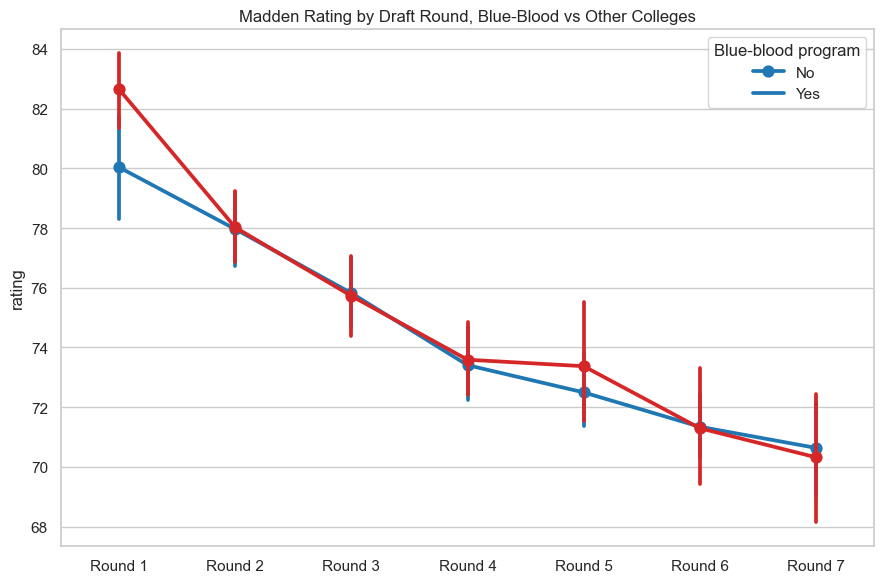

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = has_draft_info.dropna(subset=["real_draft_round"]).copy()
sns.pointplot(
    data=plot_df, x="draft_bucket", y="rating", hue="is_blue_blood",
    order=[b for b in bucket_order if b != "Undrafted"], ax=ax, errorbar=("ci", 95),
    palette={True: "#d62728", False: "#1f77b4"},
)
ax.set_title("Madden Rating by Draft Round, Blue-Blood vs Other Colleges")
ax.set_xlabel("")
ax.legend(title="Blue-blood program", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

**Takeaway:** the raw blue-blood rating edge mostly reflects a selection effect — blue-blood programs
recruit and produce more early-round picks, and Madden rating tracks draft round strongly on its own (as
shown above). Once we compare within the same draft round, the blue-blood/other gap narrows substantially
and is inconsistent in direction across rounds with these sample sizes, suggesting college brand doesn't
carry much *independent* signal about Madden's rating beyond what draft slot already captures — consistent
with draft position being the league's (and Madden's) primary distillation of amateur scouting information.

## 4. Aging curves: when do players (and their ratings) peak?

For each broad position group we plot mean Madden `rating` against `years_pro`, and, for the positions with
individually-attributable efficiency stats (QB, WR, RB), mean real per-play efficiency against `years_pro`,
to see whether the *rating* aging curve (built from track record + current-season reads) tracks the
*real performance* aging curve or lags/leads it.

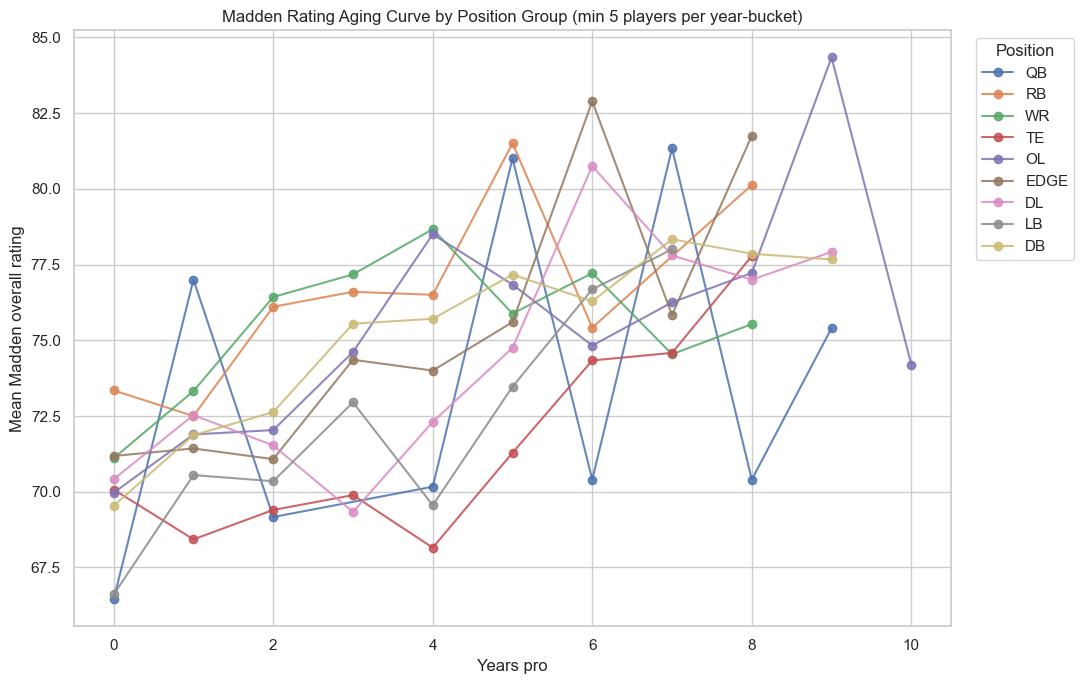

Rating-implied peak year (years_pro at max mean rating), by position:
WR      4
RB      5
DL      6
EDGE    6
LB      7
QB      7
DB      7
TE      8
OL      9
dtype: int64


In [7]:
MAX_YEARS = 12  # beyond this the bucket sizes get too thin per position to be meaningful
curve_positions = ["QB", "RB", "WR", "TE", "OL", "EDGE", "DL", "LB", "DB"]

fig, ax = plt.subplots(figsize=(11, 7))
for pos in curve_positions:
    sub = df_real[(df_real["position_group"] == pos) & (df_real["years_pro"] <= MAX_YEARS)]
    curve = sub.groupby("years_pro")["rating"].mean()
    curve = curve[curve.index.map(lambda yp: (sub["years_pro"] == yp).sum() >= 5)]  # min 5 players/bucket
    ax.plot(curve.index, curve.values, marker="o", label=pos, alpha=0.85)

ax.set_title("Madden Rating Aging Curve by Position Group (min 5 players per year-bucket)")
ax.set_xlabel("Years pro")
ax.set_ylabel("Mean Madden overall rating")
ax.legend(title="Position", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

peak_years = {}
for pos in curve_positions:
    sub = df_real[(df_real["position_group"] == pos) & (df_real["years_pro"] <= MAX_YEARS)]
    curve = sub.groupby("years_pro")["rating"].mean()
    counts = sub.groupby("years_pro")["rating"].count()
    curve = curve[counts >= 5]
    if len(curve):
        peak_years[pos] = curve.idxmax()
print("Rating-implied peak year (years_pro at max mean rating), by position:")
print(pd.Series(peak_years).sort_values())

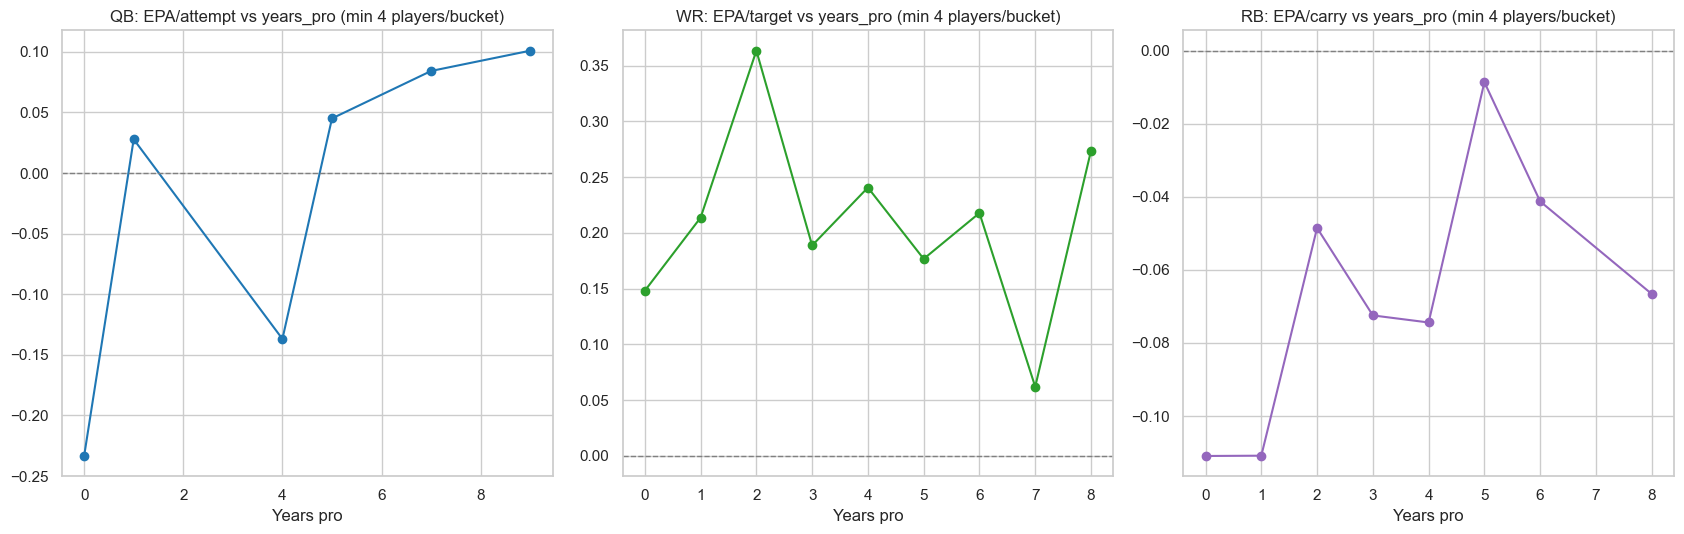

In [8]:
qb_e = df_real[(df_real["position_group"] == "QB") & (df_real["real_attempts"] > 50)].copy()
qb_e["epa_per_att"] = qb_e["real_passing_epa"] / qb_e["real_attempts"]
wr_e = df_real[(df_real["position_group"] == "WR") & (df_real["real_targets"] >= 15)].copy()
wr_e["epa_per_target"] = wr_e["real_receiving_epa"] / wr_e["real_targets"]
rb_e = df_real[(df_real["position_group"] == "RB") & (df_real["real_carries"] >= 15)].copy()
rb_e["epa_per_carry"] = rb_e["real_rushing_epa"] / rb_e["real_carries"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, sub, metric, label, color in [
    (axes[0], qb_e, "epa_per_att", "QB: EPA/attempt", "#1f77b4"),
    (axes[1], wr_e, "epa_per_target", "WR: EPA/target", "#2ca02c"),
    (axes[2], rb_e, "epa_per_carry", "RB: EPA/carry", "#9467bd"),
]:
    sub = sub[sub["years_pro"] <= MAX_YEARS]
    counts = sub.groupby("years_pro")[metric].count()
    curve = sub.groupby("years_pro")[metric].mean()
    curve = curve[counts >= 4]
    ax.plot(curve.index, curve.values, marker="o", color=color)
    ax.axhline(0, color="grey", ls="--", lw=1)
    ax.set_title(f"{label} vs years_pro (min 4 players/bucket)")
    ax.set_xlabel("Years pro")

plt.tight_layout()
plt.show()

**Takeaway:** Madden's rating aging curves broadly match football convention — running backs and defensive
backs peak (rating-wise) earliest and decline soonest, offensive linemen and quarterbacks hold rating later
into their careers, matching notebook 01's finding that QBs and specialists have the longest tails. The real
on-field efficiency curves (QB/WR/RB) are noticeably choppier year-to-year than the rating curves, which
makes sense: rating is a smoothed, track-record-weighted assessment updated incrementally, while single-
season EPA-based efficiency is a much higher-variance snapshot, especially once the bucket thins out at
higher `years_pro`. Where they roughly agree — QB efficiency staying strong well past year 5, RB efficiency
(already the noisiest metric in this whole project, per notebook 02) showing no clean trend — the pattern
reinforces rather than contradicts the rating curve, but should be read with the wide error bars an
unshown-but-implied small-n aging cut deserves.

## 5. Hidden gems: outperforming Madden's rating given draft slot

We define a "hidden gem" as a player whose *real 2025 performance* (pooled EPA-based efficiency, z-scored
within position as in notebook 02) substantially exceeds what their Madden `rating` would predict, filtered
to players drafted on day 3 (rounds 4-7) or undrafted — i.e., real production that Madden hasn't fully
caught up to yet for a player the league gave little draft capital.

In [9]:
def zscore(s):
    return (s - s.mean()) / s.std()

perf_pool = []
for sub, metric_col, label in [(qb, "epa_per_att", "EPA/attempt (QB)"),
                                (wr, "epa_per_target", "EPA/target (WR)")]:
    tmp = sub[["name", "team", "position", "rating", "real_draft_round", "years_pro", metric_col]].copy()
    tmp = tmp.rename(columns={metric_col: "perf_metric"})
    tmp["perf_label"] = label
    perf_pool.append(tmp)

rb2 = df_real[(df_real["position_group"] == "RB") & (df_real["real_carries"] >= 40)].copy()
rb2["epa_per_carry"] = rb2["real_rushing_epa"] / rb2["real_carries"]
tmp = rb2[["name", "team", "position", "rating", "real_draft_round", "years_pro", "epa_per_carry"]].rename(
    columns={"epa_per_carry": "perf_metric"}
)
tmp["perf_label"] = "EPA/carry (RB)"
perf_pool.append(tmp)

perf = pd.concat(perf_pool, ignore_index=True)
perf["rating_z"] = perf.groupby("position")["rating"].transform(zscore)
perf["perf_z"] = perf.groupby("position")["perf_metric"].transform(zscore)
perf["gap"] = perf["perf_z"] - perf["rating_z"]  # positive = outperforming rating

day3_or_udfa = perf[(perf["real_draft_round"].isna()) | (perf["real_draft_round"] >= 4)]
print(f"Day-3/UDFA players in the pooled performance sample: {len(day3_or_udfa)}")

hidden_gems = day3_or_udfa.sort_values("gap", ascending=False).head(15)
hidden_gems[["name", "team", "position", "rating", "real_draft_round", "years_pro", "perf_label", "perf_metric", "gap"]]

Day-3/UDFA players in the pooled performance sample: 85


,name,team,position,rating,real_draft_round,years_pro,perf_label,perf_metric,gap
224,Audric Estime,New Orleans Saints,Halfback,68,5.0,1,EPA/carry (RB),0.101917,3.341248
88,Kayshon Boutte,New England Patriots,Wide Receiver,80,6.0,2,EPA/target (WR),0.801312,2.382655
214,Chris Rodriguez Jr,Washington Commanders,Halfback,72,6.0,2,EPA/carry (RB),0.055335,2.264238
136,Jalen Coker,Carolina Panthers,Wide Receiver,74,NaN,1,EPA/target (WR),0.508273,2.093489
108,DeMario Douglas,New England Patriots,Wide Receiver,77,6.0,2,EPA/target (WR),0.611788,2.062459
209,Ty Johnson,Buffalo Bills,Halfback,74,6.0,6,EPA/carry (RB),0.055265,1.985459
217,Malik Davis,Dallas Cowboys,Halfback,71,NaN,3,EPA/carry (RB),0.015642,1.959274
129,Ryan Flournoy,Dallas Cowboys,Wide Receiver,75,6.0,1,EPA/target (WR),0.511336,1.954749
128,Kalif Raymond,Detroit Lions,Wide Receiver,75,NaN,8,EPA/target (WR),0.506836,1.936372
212,Jeremy McNichols,Washington Commanders,Halfback,73,5.0,9,EPA/carry (RB),0.032782,1.872989


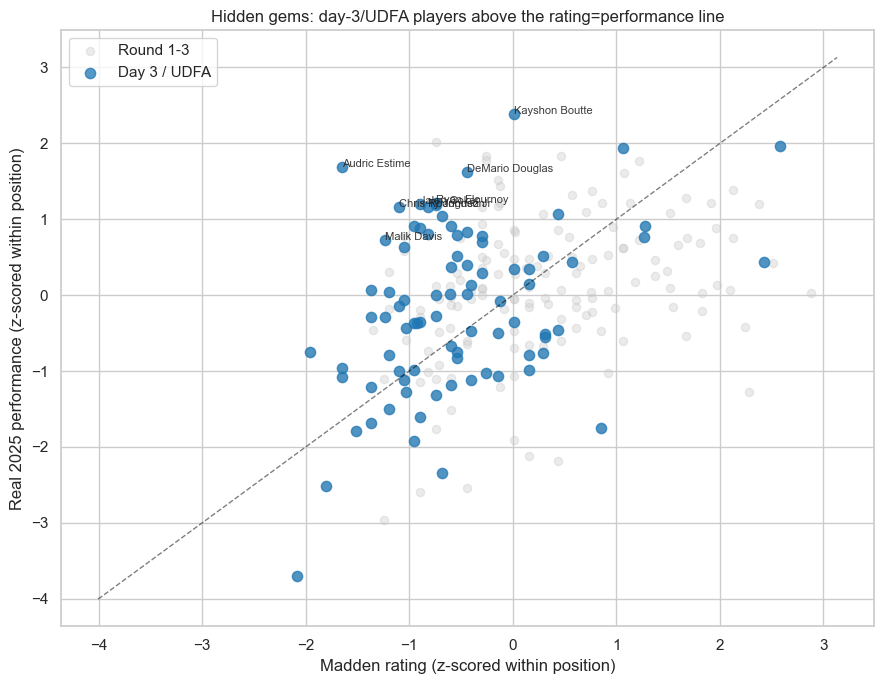

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(perf["rating_z"], perf["perf_z"], alpha=0.35, s=35, color="#c7c7c7", label="Round 1-3")
ax.scatter(day3_or_udfa["rating_z"], day3_or_udfa["perf_z"], alpha=0.75, s=55, color="#1f77b4", label="Day 3 / UDFA")
for _, row in hidden_gems.head(8).iterrows():
    ax.annotate(row["name"], (row["rating_z"], row["perf_z"]), fontsize=8, alpha=0.9)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, color="black", ls="--", lw=1, alpha=0.5)
ax.set_xlabel("Madden rating (z-scored within position)")
ax.set_ylabel("Real 2025 performance (z-scored within position)")
ax.set_title("Hidden gems: day-3/UDFA players above the rating=performance line")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** the flagged list surfaces day-3/undrafted players whose 2025 efficiency outpaces what their
current Madden rating implies — exactly the profile scouts and analytics departments look for when
identifying "value" outside the first two draft rounds. Because Madden ratings update on a lag relative to
in-season performance (as also seen with the over/underrated contract cuts in notebook 02), some of these
names are best read as "rating hasn't caught up yet" rather than a permanent blind spot, but the pattern as
a whole is a reminder that draft capital and even current rating are still probabilistic priors, not a
ceiling on what a player can become.

## Summary

- **Draft capital -> rating**: a clean, monotonic relationship — rating falls from round 1 to round 7 to
  undrafted, holding even when restricted to young players (controlling for the "aged into a starting job"
  survivor effect), showing draft slot is a real, independent signal in how Madden assigns ratings.
- **Draft capital -> real performance**: much noisier than the rating relationship, consistent with the
  football-analytics consensus that draft slot predicts *opportunity* far better than it predicts
  *realized on-field efficiency*.
- **College pedigree**: blue-blood programs show a rating edge in aggregate, but it mostly washes out once
  compared within the same draft round — pedigree looks like a selection effect on draft capital rather than
  independent signal.
- **Aging curves**: Madden's rating curves match conventional NFL career-arc wisdom (RB/DB peak and decline
  earliest, QB/OL hold value longest); real single-season efficiency curves are much choppier, as expected
  from small per-bucket samples and higher metric variance.
- **Hidden gems**: a handful of day-3/UDFA players post 2025 efficiency well above what their current rating
  implies — plausible under-the-radar value picks, or early signs Madden's rating hasn't caught up yet.